# Random Forest Regression

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('student-mat.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [3]:
# Encoding categorical data

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 2, 3, 4, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21 ])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [4]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Training the Random Forest Regression model on the whole dataset

In [5]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [6]:
# Predicting the Test set results

y_pred = regressor.predict(X_test)

print("Predicted values:")
print(y_pred)

print("Actual values:")
print(y_test)

Predicted values:
[14.21       11.08       10.12       15.95       15.79       12.31
 12.94       11.06        9.17       15.26        8.44       11.25
 10.8         7.6        15.2        13.88       13.11        8.25
  9.42       15.12        3.02        0.97        1.79       15.03
 12.68       16.13       10.35       18.85        0.48       13.11
  1.07        8.13066667  8.07        6.77366667 12.64       10.49
 12.7        18.1         5.01        8.34976984  8.34976984 18.66
  7.963       8.54        9.61        1.46       11.93        1.38
 12.43        4.36        9.27       18.19       10.75        3.54
 11.64        7.98        8.99       12.71       14.88       13.6
 12.82       13.6        13.7        15.14        5.01        8.34976984
 18.17       12.66        6.1872619   9.27        9.22       13.64
  7.46066667  0.52        8.83        7.89       11.05       18.04
  3.08      ]
Actual values:
[14 10  9 15 16 12 14 11  9 15 10 11 10  8 15 14 12  0 10 16  0  0  8 16
 12 

In [7]:
# Evaluating the model

from sklearn.metrics import r2_score, mean_absolute_error
print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 score: 0.8435191922357823
MAE: 1.2555463130399838


In [8]:
# Extracting Feature Importance

original_feature_names = dataset.columns[1:-1]

encoded_feature_names = ct.get_feature_names_out(original_feature_names)

feature_importance = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': regressor.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                   Feature  Importance
55           remainder__G2    0.772011
53     remainder__absences    0.120845
41          remainder__age    0.010779
52       remainder__health    0.007695
54           remainder__G1    0.006005
47       remainder__famrel    0.005679
26  encoder__schoolsup_yes    0.005543
48     remainder__freetime    0.005400
51         remainder__Walc    0.005205
46     remainder__failures    0.004860
18  encoder__reason_course    0.003386
43         remainder__Fedu    0.003137
25   encoder__schoolsup_no    0.003078
42         remainder__Medu    0.002691
49        remainder__goout    0.002614


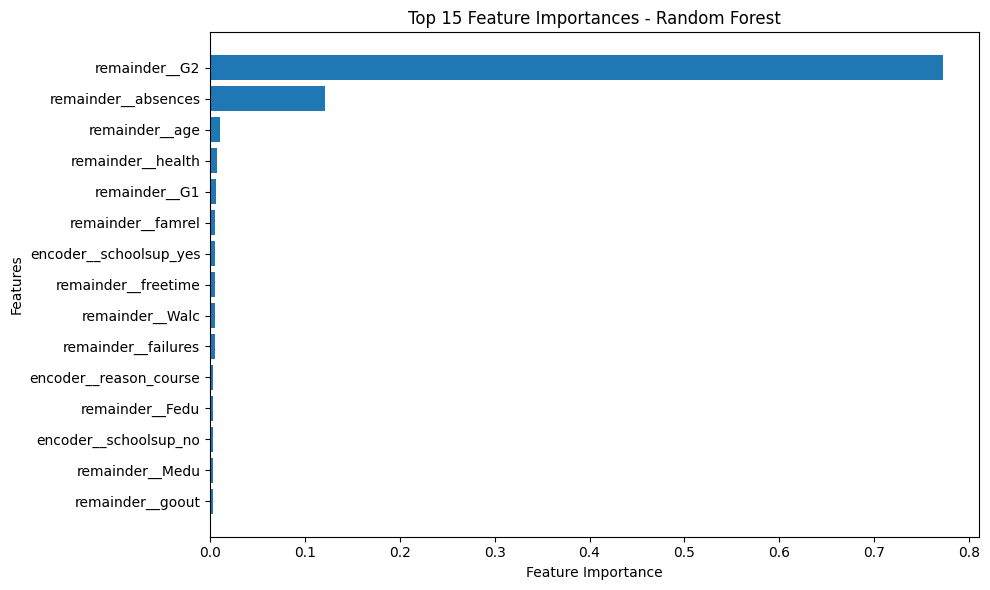

In [9]:
# Plotting Feature Importance

top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()